# 🧠 Modelo 1: Red Neuronal Simple (MLP)

Este notebook entrena una red neuronal simple con una única capa oculta para la clasificación de imágenes OCT. El modelo se carga desde el archivo `modelos/modelo_simple_nn.py`.

---

In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_simple_nn as nn_model

print("✅ Librerías importadas")

✅ Librerías importadas


In [7]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ {len(gpus)} GPU(s) detectadas")

print(gpus)

[]


In [8]:
# Descargar y preparar dataset 
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")

data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    train_subset_fraction=0.4, # Usamos el 40% para mayor velocidad
    optimize=False
)

Resuming download from 548405248 bytes (6643917524 bytes left)...
Resuming download to C:\Users\pablo\.cache\kagglehub\datasets\anirudhcv\labeled-optical-coherence-tomography-oct\2.archive (548405248/7192322772) bytes left.


100%|██████████| 6.70G/6.70G [03:05<00:00, 35.9MB/s] 

Extracting files...


✅ Dataset en: C:\Users\pablo\.cache\kagglehub\datasets\anirudhcv\labeled-optical-coherence-tomography-oct\versions\2\Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (64, 64)
   • Batch size: 32
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 40.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
   ⚠️  Usando 40.0% del dataset de entrenamiento
   ⚠️  Batches: 956 de 2392
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      956 batches
Validation: 684 batches
Test:       342 batches



In [9]:
# Crear y compilar el modelo
model = nn_model.create_simple_nn(input_shape=(64, 64, 1), num_classes=4, hidden_units=32)
model = nn_model.compile_model(model)
nn_model.print_model_summary(model)


                    📊 ARQUITECTURA DEL MODELO
Model: "SimpleNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 hidden (Dense)              (None, 32)                131104    
                                                                 
 output (Dense)              (None, 4)                 132       
                                                                 
Total params: 131,236
Trainable params: 131,236
Non-trainable params: 0
_________________________________________________________________

📈 RESUMEN DE PARÁMETROS
   • Parámetros totales: 131,236
   • Parámetros entrenables: 131,236
   • Capas: 3



In [10]:
# Entrenamiento
EPOCHS = 20
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
956/956 [==============================] - 23s 20ms/step - loss: 2.0102 - accuracy: 0.4678 - val_loss: 1.1804 - val_accuracy: 0.4702
Epoch 2/20
956/956 [==============================] - 14s 14ms/step - loss: 1.1731 - accuracy: 0.4716 - val_loss: 1.1647 - val_accuracy: 0.4702
Epoch 3/20
956/956 [==============================] - 14s 15ms/step - loss: 1.1685 - accuracy: 0.4713 - val_loss: 1.1638 - val_accuracy: 0.4702
Epoch 4/20
956/956 [==============================] - 14s 14ms/step - loss: 1.1682 - accuracy: 0.4713 - val_loss: 1.1637 - val_accuracy: 0.4702
Epoch 5/20
956/956 [==============================] - 14s 14ms/step - loss: 1.1679 - accuracy: 0.4717 - val_loss: 1.1637 - val_accuracy: 0.4702
Epoch 6/20
956/956 [==============================] - 14s 14ms/step - loss: 1.1681 - accuracy: 0.4715 - val_loss: 1.1637 - val_accuracy: 0.4702
Epoch 7/20
956/956 [==============================] - 14s 14ms/step - loss: 1.1680 - accuracy: 0.4717 - val_loss: 1.1637 - val_accuracy:

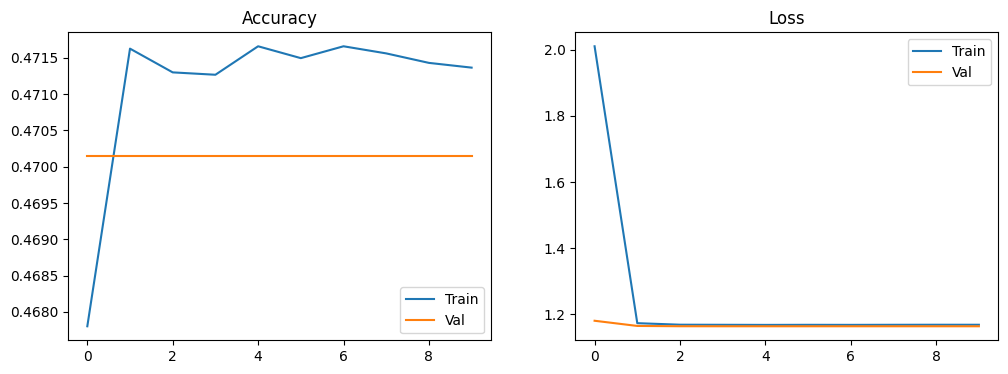

In [11]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

In [12]:
# Evaluación final
loss_train, acc_train = model.evaluate(train_ds, verbose=0)
loss_val, acc_val = model.evaluate(val_ds, verbose=0)
loss_test, acc_test = model.evaluate(test_ds, verbose=0)

print(f"Resultados: Train={acc_train:.4f}, Val={acc_val:.4f}, Test={acc_test:.4f}")
print(f"Parámetros del modelo: {model.count_params():,}")

Resultados: Train=0.4716, Val=0.4702, Test=0.4700
Parámetros del modelo: 131,236
